## Calculate SST and wind composites and IOD time series for IOD+/-, for climate Box.

Using ERA5.

In [1]:
# specify True if large ERA5 data sets are not available 
large_datasets_are_available=False

In [2]:
# load libraries, read time series data:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from netCDF4 import Dataset
import cartopy.crs as ccrs
import matplotlib.ticker as mticker
from datetime import datetime, timedelta
import matplotlib.patches as mpatches
import pickle

# font required by PUP:
plt.rcParams['font.family'] = 'Myriad Pro'
fontsize=9
plt.rcParams['font.size'] = fontsize
plt.rcParams.update({'font.size': fontsize})

if large_datasets_are_available:
    vars2save=[]
else:
    print("\nextracting variables: ",end="")
    pickle_filename='Box-IOD-composites-timeseries-ERA5.pickle'
    savedir='../../Data-for-teaching-staff/Boxes/'
    with open(savedir+pickle_filename, 'rb') as file:
            d = pickle.load(file)
            # print information about each extracted variable:
            for key in list(d.keys()):
                print(key,",",end="")
                #print(\"; type=\",type(d[key]))
            globals().update(d)
    print(" done.\n")

# read atmospheric grid information:
if large_datasets_are_available:
    data_dir="/Users/eli/Downloads/"
    file="U10.nc"
    ncfile = Dataset(data_dir+file, 'r');
    lat = ncfile.variables['latitude'][:]
    lon = ncfile.variables['longitude'][:]
    times=ncfile.variables['time'][:]

    # dont use data from partial year in 2020:
    times=times[:-8]
    # open SST file:
    data_dir="/Users/eli/Downloads/"
    file="SST.nc"
    ncfile= Dataset(data_dir+file, 'r');
    SST= ncfile.variables['sst']

    # open U,V files:
    data_dir="/Users/eli/Downloads/"
    file="U10.nc"
    ncfile= Dataset(data_dir+file, 'r');
    U10= ncfile.variables['u10']
    file="V10.nc"
    ncfile= Dataset(data_dir+file, 'r');
    V10 = ncfile.variables['v10']

    # get grid/ time limits:
    Nt,Nz,Ny,Nx=U10.shape

    # save for use if large data are not available:
    vars2save.extend([lon,lat,times,Nt,Nz,Ny,Nx])

    
# calculate dates and month for each day in the record: model times are hours since 1900-01-01 00:00:00.0
timestamp0=datetime.timestamp(datetime.fromisoformat('1900-01-01'))+20*60+40
months=np.zeros(len(times))
dates=[]
idate=-1
for time in times:
    idate=idate+1
    date=datetime.fromtimestamp((time*3600+timestamp0))
    dates.append(date)
    month=dates[idate].month
    months[idate]=month
    #print(time,date,month)
print("calculated months time series.")

# initialize monthly climatoloigy arrays:
U10_climatology=np.zeros((12,Ny,Nx))
V10_climatology=np.zeros((12,Ny,Nx))
SST_climatology=np.zeros((12,Ny,Nx))

if large_datasets_are_available:
    print("dimensions of U10,V10:",U10.shape)
    print("dimensions of SST:",SST.shape)
    print("first time:",dates[0],",last time:",dates[-1])


extracting variables: lon ,lat ,times ,Nt ,Nz ,Ny ,Nx ,IOD_east_timeseries ,IOD_west_timeseries ,SST_climatology ,SST_composite_IODm ,SST_composite_IODp , done.

calculated months time series.


## Read pre-calculated IOD time series from NOAA that is updated regularly:

In [3]:
# Initialize lists to store monthly values and corresponding times
monthly_values = []
times = []

# Open the data file
with open('../../Data-for-teaching-staff/Boxes/IOD/dmi.had.long.data', 'r') as f:
    # Skip the first line
    next(f)
    for line in f:
        # Split the line into tokens
        tokens = line.strip().split()
        if not tokens:
            continue  # Skip empty lines
        # Convert the first token to float to get the year
        year = float(tokens[0])
        # Stop reading if the year is -9999
        if year == -9999:
            break
        # Extract the twelve monthly values
        months = tokens[1:]
        # Check if there are exactly 12 monthly values
        if len(months) != 12:
            print(f"Warning: Year {int(year)} does not have 12 monthly values.")
            continue
        # Process each month's value
        for idx, val in enumerate(months):
            val_float = float(val)
            # Handle -9999 as NaN
            if val_float == -9999:
                monthly_values.append(np.nan)
            else:
                monthly_values.append(val_float)
            # Calculate the time for each month
            time = year + (idx + 0.5) / 12
            times.append(time)

# Convert lists to NumPy arrays
monthly_IOD_values_array = np.array(monthly_values)
monthly_IOD_times_array = np.array(times)

print("done.")

done.


In [4]:
# define some functions to be able to process all files efficiently without running into memory problems

def calculate_SST_index_timeseries(lat_min,lat_max,lon_min,lon_max):
    """ calculate a monthly time series of IOD."""
    print("calculate_SST_index_timeseries... ",end="")
    index_timeseries=np.zeros(len(times))
    # produce index arrays in lat and lon used for averaging over desired region:
    ilat=np.logical_and(lat<=lat_max,lat>=lat_min)
    ilon=np.logical_and(lon<=lon_max,lon>=lon_min)
    # calculate spatial average to find time index:
    index_timeseries=np.nanmean(SST[:,0,ilat,ilon],axis=(1,2))

    # now remove monthly climatology from the NINO3 time series:
    index_monthly_climatology=np.zeros(12)
    for m in range(12):
        index_monthly_climatology[m]=np.mean(index_timeseries[m::12])
        index_timeseries[m::12]= \
           index_timeseries[m::12]-index_monthly_climatology[m]

    print(" done.")
    return index_timeseries


def calculate_composite(variable,mask_timeseries,remove_monthly_climatology,monthly_climatology):
    first_time_read=True
    iavg=0
    for t in range(len(times)):
        #print(t,",",end="")
        # read data:
        if not np.isnan(mask_timeseries[t]):
            #print(t,",",end="")
            if first_time_read:
                first_time_read=False
                variable_avg=1.0*variable[t,0,:,:]
            else:
                variable_avg=variable_avg+variable[t,0,:,:]
            if remove_monthly_climatology:
                variable_avg=variable_avg-monthly_climatology[int(months[t])-1,:,:]
            iavg=iavg+1

    if iavg>0:
        variable_avg=variable_avg/iavg
        variable_avg[variable_avg.mask]=np.nan
    else:
        print("\n\n\n*** error: no times to composite over.\n\n\n")
    #print(" done.")
    
    return variable_avg

print("function defenitions updated.")

function defenitions updated.


In [5]:
# calculate IOD index:

#fig=plt.figure(figsize=(5,3),dpi=300)

if large_datasets_are_available:
    # east indian ocean:
    lat_min=-10
    lat_max=0
    lon_min=90
    lon_max=110
    IOD_east_timeseries=calculate_SST_index_timeseries(lat_min,lat_max,lon_min,lon_max)
    IOD_east_timeseries=IOD_east_timeseries[0:len(dates)]
    #plt.plot(IOD_east,lw=1)

    # west indian ocean:
    lat_min=-10
    lat_max=10
    lon_min=50
    lon_max=70
    IOD_west_timeseries=calculate_SST_index_timeseries(lat_min,lat_max,lon_min,lon_max)
    IOD_west_timeseries=IOD_west_timeseries[0:len(dates)]
    #plt.plot(IOD_west,lw=1)
    #plt.plot(dates,IOD_timeseries,lw=0.5)

    # save for use if large data are not available:
    vars2save.extend([IOD_east_timeseries,IOD_west_timeseries])


IOD_timeseries=IOD_west_timeseries-IOD_east_timeseries


# prepare mask time series for calculating composites:

mean=np.mean(IOD_timeseries)
std=np.std(IOD_timeseries)
print("IOD mean, std=",mean,std)
IODp_threshold=mean+std*1
IODm_threshold=mean-std*1

# calculate masks:
IODp_mask_timeseries=IOD_timeseries*0+1.0
IODp_mask_timeseries[IOD_timeseries<IODp_threshold]=np.nan
num_IODp_months=np.nansum(IODp_mask_timeseries)

IODm_mask_timeseries=IOD_timeseries*0+1.0
IODm_mask_timeseries[IOD_timeseries>IODm_threshold]=np.nan
num_IODm_months=np.nansum(IODm_mask_timeseries)


print("IODp_threshold=",IODp_threshold, ", number of IODp months=",num_IODp_months
      ,"=",100*num_IODp_months/len(IOD_timeseries),"%");
print("IODm_threshold=",IODm_threshold, ", number of IODp months=",num_IODm_months
      ,"=",100*num_IODm_months/len(IOD_timeseries),"%");

IOD mean, std= -0.001536079232857186 0.4979490975947007
IODp_threshold= 0.4964130183618435 , number of IODp months= 63.0 = 12.778904665314402 %
IODm_threshold= -0.4994851768275579 , number of IODp months= 62.0 = 12.57606490872211 %


In [6]:
# use indices to calculate monthly climatologies and composites:
   
if large_datasets_are_available:
    print("Calculating monthly climatologies...",end="")
    remove_monthly_climatology=False
    for m in range(0,12):
        print(m,",",end="")
        climatology_mask_timeseries=np.zeros(IODp_mask_timeseries.shape)*np.nan
        climatology_mask_timeseries[m::12]=1
        monthly_climatology=np.nan
        SST_climatology[m,:,:]=calculate_composite(SST,climatology_mask_timeseries,remove_monthly_climatology,monthly_climatology)
    print(" Done calculating monthly climatologies.")

    # calculate composites for El Nina and La Nina:
    print("Calculating IOD+/- SST composites...",end="")
    remove_monthly_climatology=True
    SST_composite_IODp=calculate_composite(SST,IODp_mask_timeseries,remove_monthly_climatology,SST_climatology)
    SST_composite_IODm=calculate_composite(SST,IODm_mask_timeseries,remove_monthly_climatology,SST_climatology)
    print(" Done calculating IOD+/- composites.")
    
    # save for use if large data are not available:
    vars2save.extend([SST_climatology,SST_composite_IODm,SST_composite_IODp])
    
print("done.")

done.


location of xticklabels is different in final pdf.


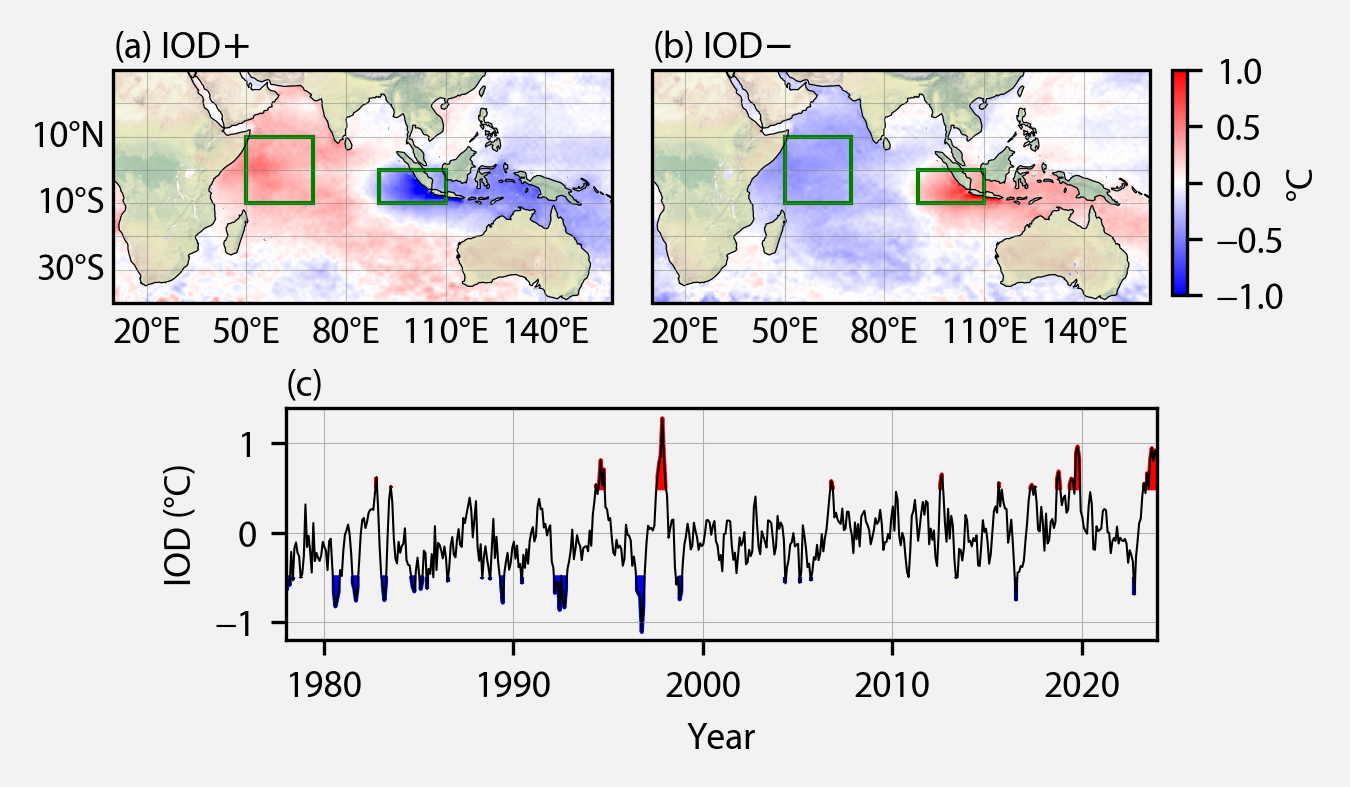

In [7]:
# draw the climatologies and composites:
print("location of xticklabels is different in final pdf.")
# initialize figure:
projection=ccrs.PlateCarree(central_longitude=0.0);
fig=plt.figure(figsize=(5,2.5),dpi=300);
shrink=0.62


# IOD+:
# -----
axes=fig.add_subplot(2,6,(1,3), projection=ccrs.PlateCarree(0))
axes.set_extent([10, 160, -40, 30], crs=ccrs.PlateCarree(0))
axes.coastlines(resolution='110m',lw=0.3)
axes.stock_img()
plt.set_cmap('bwr')
DATA=1.0*SST_composite_IODp[:,:]
c=axes.pcolormesh(lon,lat,DATA,vmin=-1,vmax=1)
axes.set_title('(a) IOD$+$',loc="left",pad=3,fontsize=fontsize)
axes.add_patch(mpatches.Rectangle(xy=[50, -10], width=20, height=20,edgecolor="g", lw=1, facecolor='none',transform=ccrs.PlateCarree()))
axes.add_patch(mpatches.Rectangle(xy=[90, -10], width=20, height=10,edgecolor="g", lw=1, facecolor='none',transform=ccrs.PlateCarree()))
gl = axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                  linewidth=0.25, color='gray', alpha=0.5, linestyle='-')
gl.left_labels = True
gl.bottom_labels = True
# add tick makrs, labels are already dealt with by cartopy, so turn that off.
# axes.set_xticks([20, 50, 80, 110, 140])
# axes.set_xticklabels("")
gl.xlocator = mticker.FixedLocator([20, 50, 80, 110, 140])
gl.rotate_labels=False
#gl.xpadding=20 # space between xtick labes and plot
#gl.right_labels = False
#gl.top_labels = False
gl.ypadding=2
gl.xpadding=3


# IOD-:
# -----
axes=fig.add_subplot(2,6,(4,6), projection=ccrs.PlateCarree(0))#grid[0, 0])
axes.set_extent([10, 160, -40, 30], crs=ccrs.PlateCarree())
axes.coastlines(resolution='110m',lw=0.3)
axes.stock_img()
plt.set_cmap('bwr')
DATA=1.0*SST_composite_IODm[:,:]
c=axes.pcolormesh(lon,lat,DATA,vmin=-1,vmax=1)
axes.set_title('(b) IOD$-$',loc="left",pad=3,fontsize=fontsize)
#axes.text(0.03, 0.93, "(b)", transform=axes.transAxes, fontsize=12,
#        verticalalignment='top', bbox=props)
axes.add_patch(mpatches.Rectangle(xy=[50, -10], width=20, height=20,edgecolor="g" \
                , lw=1, facecolor='none',transform=ccrs.PlateCarree()))
axes.add_patch(mpatches.Rectangle(xy=[90, -10], width=20, height=10,edgecolor="g" \
                , lw=1, facecolor='none',transform=ccrs.PlateCarree()))
gl = axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=False,
                  linewidth=0.25, color='gray', alpha=0.5, linestyle='-')
gl.bottom_labels = True
# add tick makrs, labels are already dealt with by cartopy, so turn that off.
# axes.set_xticks([20, 50, 80, 110, 140])
# axes.set_xticklabels("")
gl.xlocator = mticker.FixedLocator([20, 50, 80, 110, 140])
gl.rotate_labels=False
#gl.xpadding=20 # space between xtick labes and plot
#gl.left_labels = False
#gl.right_labels = False
#gl.top_labels = False
gl.ypadding=2
gl.xpadding=3

# joint colorbar for both upper panels:
ax2 = fig.add_axes([0.86, 0.63, 0.01, 0.30])
clb=fig.colorbar(c,cax=ax2, ticks=np.arange(-1,1.5,0.5),anchor=(0.3,0.5))
clb.set_label('°C',labelpad=0)



# IOD time series:
# ------------------
std=np.std(IOD_timeseries)
axes=fig.add_subplot(2,6,(9,11))
axes.plot(monthly_IOD_times_array, monthly_IOD_values_array,lw=0.5,label="IOD",color="k")
plt.yticks([-1,0,1,2])
y1=1.0*monthly_IOD_values_array
y1[monthly_IOD_values_array<std]=np.nan
y1=y1*0+std
axes.fill_between(monthly_IOD_times_array, y1=y1, y2=monthly_IOD_values_array, color="r")
y2=1.0*monthly_IOD_values_array
y2[monthly_IOD_values_array>-std]=np.nan
y2=y2*0-std
axes.fill_between(monthly_IOD_times_array, y1=monthly_IOD_values_array, y2=y2, color="b")
axes.set_xlabel("Year")
axes.set_ylabel("IOD (°C)")
axes.set_title("(c)",loc="left",pad=3,fontsize=fontsize)
plt.xlim(1978, 2024);
plt.ylim(-1.2,1.4)
axes.grid(lw=0.25);

axes.set_facecolor('#f2f2f2')
fig.patch.set_facecolor('#f2f2f2')

# finalize and show plot:
plt.subplots_adjust(left=0.03,right=0.97,bottom=0.17,top=0.93,hspace=0.45,wspace=-0.65);
plt.show()

fig.savefig("Output/Box-IOD-composites-timeseries-ERA5.pdf",facecolor='#f2f2f2'
           ,bbox_inches='tight',pad_inches = 0);

In [ ]:
# pickle all vars to save:
def pickle_vars(fileName, env, variables):
    d = dict([(x, env[x]) for v in variables for x in env if v is env[x]])
    with open(fileName, 'wb') as f:
        pickle.dump(d, f)

if large_datasets_are_available:
    pickle_vars('Output/Box-IOD-composites-timeseries-ERA5.pickle',locals(),vars2save)

print("done.")